# 03 — Exploratory data analysis

**Role: Descriptive and spatial-temporal EDA.**

This notebook turns the validated national-panel EDA into a readable data-science review. It reads real project artefacts and makes small in-memory summaries and figures; it does **not** rebuild the national panel or select a model.

The analytical record is one 1 km mainland cell × predictor year. Fire recurrence is measured in a mainland-masked 2 km context.

### Reading guide

| Section | Question answered | What it does not answer |
| --- | --- | --- |
| Panel contract | Are the records complete and correctly split? | Whether a model is accurate. |
| Target distribution | How common is next-year burned area, and how does it vary over time? | Which model is best. |
| Predictor relationships | Are any inputs obviously redundant? | Whether one input causes wildfire. |
| Drift and extremes | Do later-year inputs differ from the training inputs? | Whether a value is necessarily wrong or whether the model is accurate. |

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.notebook_support import read_json_artifact, resolve_project_root
PROJECT_ROOT = resolve_project_root(PROJECT_ROOT)
eda = read_json_artifact(PROJECT_ROOT, 'reports/validation/national_panel_model_readiness_eda.json')
print(f"Loaded validated EDA for {eda['row_count']:,} cell-year rows.")

Loaded validated EDA for 891,120 cell-year rows.


## Optional EDA regeneration

The default notebook path reads the recorded validation evidence, so a reviewer can inspect the completed analysis quickly and safely. Set the switch to `True` only after the national panel has been deliberately rebuilt; it calls the same bounded EDA function as `scripts/run_national_panel_eda.py` and rewrites only EDA reports/figures.

The switch does not download data, derive new predictors, fit a model, or change the panel. Leave it as `False` for normal review.

In [2]:
REGENERATE_EDA = False
if REGENERATE_EDA:
    from src.panel_eda import run_panel_eda
    eda = run_panel_eda()
    print('Rebuilt EDA reports and figures from the national panel.')
else:
    print('Using recorded EDA artifacts. Set REGENERATE_EDA=True only for a deliberate rebuild.')

Using recorded EDA artifacts. Set REGENERATE_EDA=True only for a deliberate rebuild.


## Panel and missing-data contract

These are persisted validation results, not hand-entered numbers. Missing predictor values would block model readiness.

The first table gives the number of cell-year records in each temporal split. The second gives missing-value counts for every required analytical field: all counts must be zero. The final gate message records whether the validated EDA evidence permitted the project to continue to model design.

In [3]:
split_rows = pd.Series(eda['split_row_counts'], name='cell_year_rows').to_frame()
missingness = pd.Series(eda['missingness'], name='missing_values').to_frame()
display(split_rows)
display(missingness)
assert missingness['missing_values'].eq(0).all(), 'Validated panel has unexpected predictor missingness.'
print('Model-design gate:', eda['model_design_decision']['gate'])

,cell_year_rows
train,445560
final_test,267336
validation,178224


,missing_values
built_up_share,0
forest_shrub_share_2km,0
mean_slope_2km,0
fire_years_previous_10y_2km,0
warm_season_mean_2m_temperature_c,0
warm_season_total_precipitation_mm,0
warm_season_mean_soil_water_layer1,0
warm_season_max_monthly_2m_temperature_c,0
warm_season_min_monthly_soil_water_layer1,0
burned_share_next_year,0


Model-design gate: Model-design gate passed — modelling may begin


## Target distribution through time

`burned_share_next_year` is the proportion of a cell's land area that overlaps observed ICNF burned area in outcome year `T+1`. It is continuous, from 0 to 1, but zero-heavy because most 1 km cells do not burn in a given next year.

The table reports the target distribution by predictor year `T`; each row therefore describes the observed outcome in `T+1`. The bar chart shows the proportion of cells with an exactly zero next-year burned share. A high bar is expected in a rare-event setting. It explains why all-row error alone can be misleading and why the later two-part regression design was considered. This section is descriptive only; it does not fit or tune a model.

,row_count,zero_proportion,positive_count,mean,median,p90,p95,p99,maximum,positive_median,positive_p90
predictor_year,,,,,,,,,,,
2015,89112,0.935216,5773,0.017537,0.0,0.000000,0.007240,0.729508,1.0,0.094914,0.878668
2016,89112,0.863969,12122,0.062865,0.0,0.054614,0.696303,1.000000,1.0,0.378976,1.000000
2017,89112,0.983762,1447,0.004483,0.0,0.000000,0.000000,0.038782,1.0,0.091705,0.957225
2018,89112,0.966290,3004,0.004509,0.0,0.000000,0.000000,0.107231,1.0,0.027202,0.445275
2019,89112,0.963035,3294,0.007437,0.0,0.000000,0.000000,0.212034,1.0,0.038604,0.800994
2020,89112,0.978465,1919,0.003074,0.0,0.000000,0.000000,0.056824,1.0,0.049114,0.411908
2021,89112,0.951544,4318,0.012178,0.0,0.000000,0.000000,0.534079,1.0,0.075544,0.880264
2022,89112,0.968119,2841,0.003829,0.0,0.000000,0.000000,0.060155,1.0,0.019840,0.411781
2023,89112,0.952285,4252,0.015607,0.0,0.000000,0.000000,0.768506,1.0,0.129671,0.962214


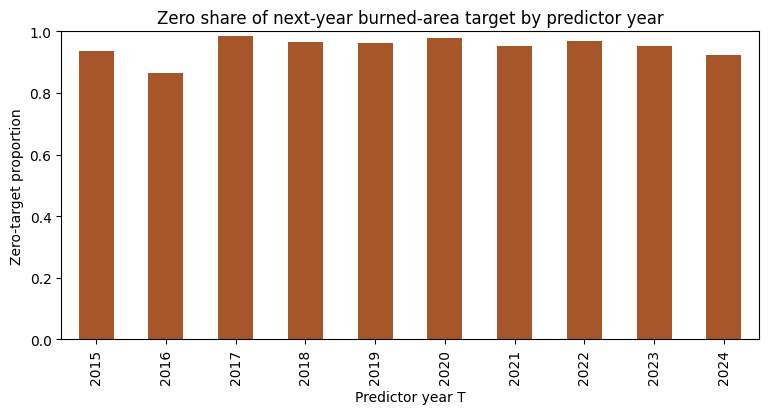

Overall zero proportion: 94.9%


In [4]:
target_by_year = pd.DataFrame.from_dict(eda['target']['by_year'], orient='index').sort_index()
target_by_year.index.name = 'predictor_year'
display(target_by_year)

fig, ax = plt.subplots(figsize=(9, 4))
target_by_year['zero_proportion'].plot(kind='bar', ax=ax, color='#a65628')
ax.set(title='Zero share of next-year burned-area target by predictor year', xlabel='Predictor year T', ylabel='Zero-target proportion', ylim=(0, 1))
plt.show()
print('Overall zero proportion:', f"{eda['target']['overall_zero_proportion']:.1%}")

## Predictor relationships

Correlation is a screening diagnostic, not causal evidence. It is useful for identifying obvious redundancy before modelling.

Each cell in the matrix is a Pearson correlation between two predictors across the national panel. Values near +1 move together, values near −1 move in opposite directions, and values near 0 have little linear relationship. The diagonal is always 1 because each predictor is perfectly correlated with itself. The printed list flags pairs with absolute correlation of at least 0.8 for review. A high correlation does not prove that a feature should be removed, nor does it show a relationship with the wildfire target.

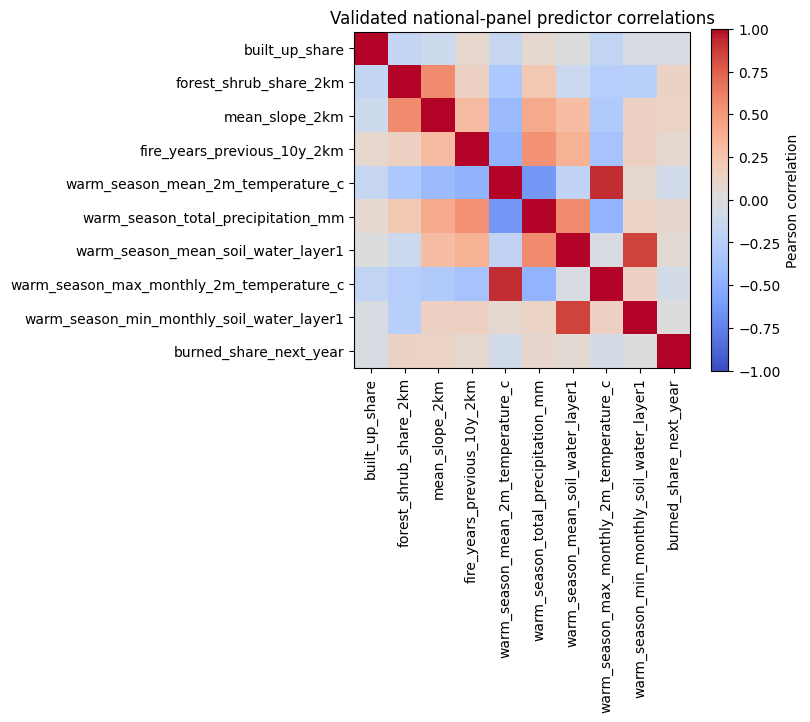

Pairs with |correlation| ≥ 0.8: [{'left': 'warm_season_mean_2m_temperature_c', 'right': 'warm_season_max_monthly_2m_temperature_c', 'correlation': 0.9195909363849064}, {'left': 'warm_season_mean_soil_water_layer1', 'right': 'warm_season_min_monthly_soil_water_layer1', 'correlation': 0.8497608358301967}]


In [5]:
correlations = pd.DataFrame(eda['correlations'])
fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(correlations, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(correlations.columns)), correlations.columns, rotation=90)
ax.set_yticks(range(len(correlations.index)), correlations.index)
fig.colorbar(image, ax=ax, label='Pearson correlation')
ax.set_title('Validated national-panel predictor correlations')
fig.tight_layout()
plt.show()
print('Pairs with |correlation| ≥ 0.8:', eda['high_redundancy_pairs_abs_ge_0_8'] or 'none recorded')

## Temporal drift and extreme-value screening

The table and plot compare each later period with the training-period predictor distribution using standardized mean differences. This identifies changed climate context or covariate shift; it does not prove that a valid physical value is an error.

For each predictor, 0 means its later-period average matches the training average. A positive value means the later period is higher; a negative value means it is lower. The size is expressed in training-period standard deviations, not as a percentage and not as an accuracy score. Small absolute differences mean the model is being used in more familiar input conditions; larger differences are a warning that later climate conditions differ from those on which it learned.

The first table and bar chart compare validation and final-test inputs separately. The final table counts values outside the training interquartile range in each split. It is a review list only: real climate extremes are retained rather than silently deleted. These diagnostics help interpret later model results and future scoring, but they do not decide whether the model is good or bad.

,validation,final_test
predictor,,
built_up_share,0.004,0.004
forest_shrub_share_2km,-0.023,-0.023
mean_slope_2km,0.000,0.000
fire_years_previous_10y_2km,0.090,-0.002
warm_season_mean_2m_temperature_c,-0.188,0.089
warm_season_total_precipitation_mm,0.678,0.849
warm_season_mean_soil_water_layer1,0.214,0.289
warm_season_max_monthly_2m_temperature_c,0.147,0.409
warm_season_min_monthly_soil_water_layer1,-0.064,-0.126


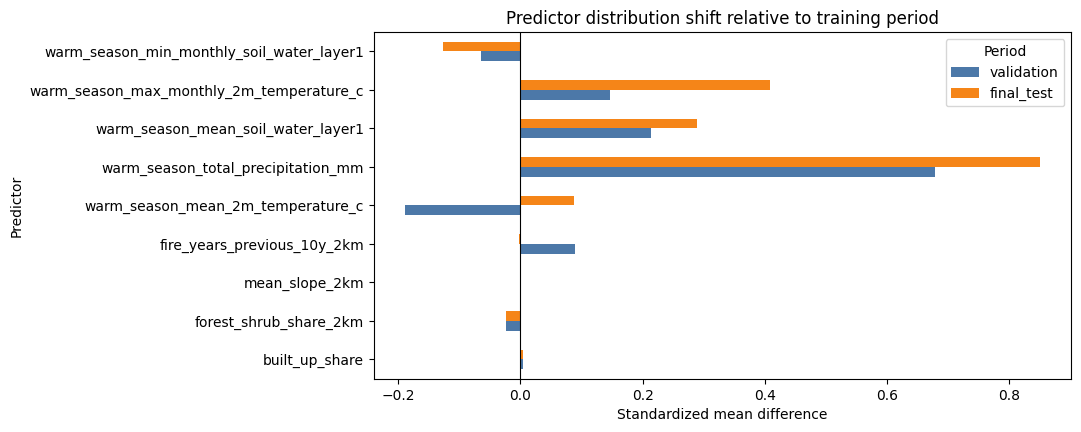

,train,validation,final_test
predictor,,,
built_up_share,70828,28720,43080
forest_shrub_share_2km,0,0,0
mean_slope_2km,0,0,0
fire_years_previous_10y_2km,0,0,0
warm_season_mean_2m_temperature_c,0,0,0
warm_season_total_precipitation_mm,2716,187,9332
warm_season_mean_soil_water_layer1,0,0,0
warm_season_max_monthly_2m_temperature_c,0,0,0
warm_season_min_monthly_soil_water_layer1,658,182,273


IQR screening identifies values for review only; physically valid precipitation is not removed because it differs from training years.


In [6]:
drift = pd.DataFrame(eda['split_standardized_mean_difference_from_train']).rename_axis('predictor')
display(drift.style.format('{:.3f}'))

fig, ax = plt.subplots(figsize=(9, 4.5))
drift.plot(kind='barh', ax=ax, color=['#4C78A8', '#F58518'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Predictor distribution shift relative to training period', xlabel='Standardized mean difference', ylabel='Predictor')
ax.legend(title='Period')
plt.show()

outlier_counts = pd.DataFrame({name: values['counts_by_split'] for name, values in eda['outlier_screen'].items()}).T
display(outlier_counts.rename_axis('predictor'))
print('IQR screening identifies values for review only; physically valid precipitation is not removed because it differs from training years.')

## Reproducibility boundary

To deliberately rebuild the panel and EDA from local raw inputs, use `python scripts/run_project.py --mode reproduce --confirm-rebuild` in a terminal. Notebook execution is intentionally read-and-explain by default so it cannot accidentally trigger a national geospatial rebuild.

For ordinary review, run this notebook from top to bottom with `REGENERATE_EDA = False`. The figures and tables are derived from `reports/validation/national_panel_model_readiness_eda.json`, keeping the displayed evidence traceable to the recorded validation artefact.